# 机器学习

## 0. 机器学习杂项

### 0.1 向量的点积 Dot Product

向量点积用于衡量两个向量在同一方向上的匹配程度。两个长度相同的向量相乘时，对应位置相乘后再求和。

公式为：

$$
\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_i b_i
$$

例如：

$$
[1, 2, 3] \cdot [4, 5, 6] = 1 \times 4 + 2 \times 5 + 3 \times 6 = 32
$$

点积常用于线性模型中，例如 $w \cdot x + b$。

In [1]:
import numpy as np
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.dot(a, b)) # 32

32


---

## 1. 监督学习 Supervised Learning

### 1.1 定义

监督学习是指：给算法一个带有**正确答案**的数据集，通过数据训练模型，让模型学习输入和输出之间的对应关系。

也就是说，监督学习的数据中既有输入 \`x\`，也有正确输出 \`y\`。

### 1.2 常见任务

| 类型 | 预测目标 | 输出特点 | 例子 |
| --- | --- | --- | --- |
| 回归 Regression | 连续数值 | 输出可以有无数种可能 | 根据房屋面积预测房价 |
| 分类 Classification | 离散类别 | 输出只属于有限类别 | 根据肿瘤特征判断良性或恶性 |

### 1.3 直观理解

- **回归算法**：预测“是多少”，例如房价、温度、销量。
- **分类算法**：预测“属于哪一类”，例如良性/恶性、垃圾邮件/正常邮件。

---

## 2. 无监督学习 Unsupervised Learning

### 2.1 定义

无监督学习是指：给定的数据只有输入 \`x\`，没有输出标签 \`y\`。算法需要自己在数据中寻找结构、规律或模式。

常见方法包括：**聚类算法**、降维算法、异常检测等。

### 2.2 聚类算法 Clustering

聚类算法会将数据分成不同的组或簇，使组内数据相似度较高，组间数据相似度较低。

例如客户细分：根据客户的购买行为，将客户分成不同的群体。

### 2.3 直观理解

无监督学习没有标准答案，算法需要自己发现数据中的隐藏结构。

---

## 3. 线性回归 Linear Regression

### 3.1 定义

线性回归是一种**监督学习算法**，主要用于**预测连续数值**。它通过拟合一条直线，描述输入变量与输出变量之间的关系。

例如房价预测：每一个数据点都表示一套房子的面积和价格。模型通过这些数据拟合出一条趋势线，然后根据新的房屋面积预测对应房价。

### 3.2 单变量线性回归

只有一个输入变量的线性回归称为**单变量线性回归**（Univariate Linear Regression）。

例如：只用房屋面积 \`x\` 预测房价 \`y\`。

### 3.3 假设函数

为了训练模型，需要将训练集输入给学习算法。监督学习算法会生成一个函数，也叫**假设函数**（Hypothesis Function），记作 $f_{w,b}(x)$。

该函数的作用是：输入 \`x\` 后，输出一个预测值 $\hat{y}$（y-hat）。

线性回归的假设函数为：

$$
f_{w,b}(x) = wx + b
$$

其中：

- $x$：输入特征
- $w$：权重参数，决定直线斜率
- $b$：偏置参数，决定直线截距
- $\hat{y}$：模型预测值

---

## 4. 代价函数 Cost Function

### 4.1 定义

代价函数用于衡量模型预测结果与真实结果之间的差距。它可以理解为模型预测的**错误程度**。

- 代价函数的值越小，表示预测越接近真实结果。
- 代价函数的值越大，表示预测误差越大。

### 4.2 线性回归中的代价函数

在线性回归中，常用的代价函数是**均方误差**（Mean Squared Error, MSE）：

$$
J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2
$$

其中：

- $J(w, b)$：代价函数
- $m$：训练样本数量
- $x^{(i)}$：第 $i$ 个训练样本的输入
- $y^{(i)}$：第 $i$ 个训练样本的真实输出
- $f_{w,b}(x^{(i)})$：模型对第 $i$ 个样本的预测值
- $w$：权重参数
- $b$：偏置参数

### 4.3 目的

训练模型的过程，就是不断调整 $w$ 和 $b$，让代价函数 $J(w,b)$ 的值尽可能小。

### 4.4 判断标准

- $J(w,b)$ 越小，说明模型预测越准确。
- $J(w,b)$ 越大，说明模型预测误差越大。

---

## 5. 梯度下降 Gradient Descent

### 5.1 定义

梯度下降是一种用于**最小化代价函数**的优化算法。它通过不断调整模型参数，使代价函数的值逐步下降，最终接近最小值。

需要注意：

- 如果代价函数是**凸函数**，通常只有一个全局最小值。
- 如果代价函数是**非凸函数**，可能存在多个局部最小值（Local Minimum）。
- 线性回归的平方误差代价函数是凸函数，因此只有一个全局最小值。

### 5.2 原理

梯度表示函数上升最快的方向。为了让代价函数变小，梯度下降会沿着梯度的反方向更新参数。

直观理解：每次都朝着“下坡最快”的方向走一步，直到接近最低点。

### 5.3 参数更新公式

单变量线性回归中，需要同时更新 $w$ 和 $b$：

$$
\begin{aligned}
w_{\text{temp}} &= w - \alpha \frac{\partial J(w,b)}{\partial w} \\
b_{\text{temp}} &= b - \alpha \frac{\partial J(w,b)}{\partial b}
\end{aligned}
$$

然后再令：

$$
w = w_{\text{temp}}, \quad b = b_{\text{temp}}
$$

这样可以保证 $w$ 和 $b$ 使用的是同一轮迭代中的旧参数，避免一个参数先更新后影响另一个参数的计算。

其中：

- $\alpha$：学习率，控制每次参数更新的步长
- $\frac{\partial J(w,b)}{\partial w}$：代价函数对 $w$ 的偏导数
- $\frac{\partial J(w,b)}{\partial b}$：代价函数对 $b$ 的偏导数

### 5.4 基本步骤

1. 初始化模型参数，例如 $w = 0$，$b = 0$。
2. 计算当前参数下的代价函数 $J(w,b)$。
3. 计算 $J(w,b)$ 对 $w$ 和 $b$ 的偏导数。
4. 根据梯度下降公式同时更新 $w$ 和 $b$。
5. 重复以上过程，直到代价函数收敛，或者达到设定的迭代次数。

### 5.5 学习率 Learning Rate

学习率 $\alpha$ 决定了每次参数更新的步长大小。

- 学习率过大：可能越过最低点，在最小值附近震荡，甚至无法收敛。
- 学习率过小：每次移动太少，收敛速度很慢。
- 学习率合适：可以稳定、较快地接近最小值。

当学习率固定时，随着模型越来越接近最小值，斜率通常会越来越小，所以每次参数更新的幅度也会逐渐变小。

### 5.6 优缺点

优点：

- 思路简单，容易实现。
- 适合参数较多、数据量较大的模型。
- 是许多机器学习和深度学习算法的基础。

缺点：

- 需要手动选择合适的学习率 $\alpha$。
- 对特征尺度比较敏感，特征差异过大时收敛会变慢。
- 对非凸函数，可能收敛到局部最小值。

### 5.7 梯度下降算法的种类

| 类型 | 每次迭代使用的数据 | 优点 | 缺点 |
| --- | --- | --- | --- |
| 批量梯度下降（Batch Gradient Descent） | 使用全部训练样本 | 梯度方向稳定，结果较准确 | 计算量大，数据集很大时训练速度较慢 |
| 随机梯度下降（Stochastic Gradient Descent） | 每次只使用一个训练样本 | 单次更新速度快，适合大规模数据 | 更新方向波动较大，结果不够稳定 |
| 小批量梯度下降（Mini-Batch Gradient Descent） | 每次使用一小批训练样本 | 兼顾计算效率和稳定性，是实际训练中常用的方法 | 需要选择合适的 batch size |

简单来说：

- **批量梯度下降**：每次看完全部数据再更新参数，代价函数中的 $m$ 是全部样本数。
- **随机梯度下降**：每次只看一个样本就更新参数，相当于每次更新只使用 1 个样本。
- **小批量梯度下降**：每次看一小批样本再更新参数，代价函数中的样本数通常是 batch size。

---

## 6. 多元线性回归 Multiple Linear Regression

### 6.1 定义

多元线性回归是指：模型有多个输入特征 $x_1, x_2, \ldots, x_n$，并通过这些特征共同预测一个连续输出 $y$。

例如房价预测中，可以同时使用面积、楼层、位置、房间数量等特征。

### 6.2 假设函数

多元线性回归的假设函数为：

$$
f_{\mathbf{w},b}(\mathbf{x}) = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$

也可以写成向量形式：

$$
f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b
$$

其中：

- $\mathbf{x}$：输入特征向量
- $\mathbf{w}$：权重向量
- $b$：偏置参数
- $\hat{y}$：模型预测值

### 6.3 代价函数

多元线性回归的代价函数仍然使用均方误差：

$$
J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} \left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)^2
$$

### 6.4 梯度下降

多元线性回归的梯度下降与单变量线性回归类似，只是需要对每一个参数 $w_j$ 都计算偏导数。

对于第 $j$ 个权重参数，偏导数为：

$$
\frac{\partial J(\mathbf{w}, b)}{\partial w_j}
= \frac{1}{m} \sum_{i=1}^{m} \left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)x_j^{(i)}
$$

偏置参数的偏导数为：

$$
\frac{\partial J(\mathbf{w}, b)}{\partial b}
= \frac{1}{m} \sum_{i=1}^{m} \left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)
$$

### 6.5 正规方程法 Normal Equation

正规方程法是另一种求解线性回归参数的方法，适用于特征数量较少、数据量较小的情况。

注意：正规方程法只适用于线性回归，不适用于逻辑回归等分类模型。

---

## 7. 特征缩放 Feature Scaling

### 7.1 定义

特征缩放是指：将不同量纲、不同取值范围的特征转换到相近的数值范围内，以便模型更稳定、更高效地训练。

例如身高的单位是米，体重的单位是千克，两者数值范围不同。如果不进行特征缩放，梯度下降可能会收敛很慢，更新路径也可能不稳定。

### 7.2 为什么需要特征缩放

1. 不同特征的数值范围差异太大时，梯度下降会更慢。
2. 特征缩放可以让代价函数的等高线更接近圆形，减少来回震荡。
3. 对基于距离或梯度的算法，特征缩放通常能明显改善训练效果。

### 7.3 常见方法

#### 标准化 Standardization

标准化会将特征转换为均值为 0、标准差为 1 的分布，也称为 **Z-score 标准化**。

$$
x' = \frac{x - \mu}{\sigma}
$$

其中：

- $x$：原始特征值
- $\mu$：特征均值
- $\sigma$：特征标准差
- $x'$：标准化后的特征值

标准差公式为：

$$
\sigma = \sqrt{\frac{1}{m}\sum_{i=1}^{m}(x^{(i)} - \mu)^2}
$$

#### 归一化 Normalization

归一化会将特征缩放到 $[0,1]$ 区间。

$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

其中：

- $\min(x)$：特征最小值
- $\max(x)$：特征最大值
- $x'$：归一化后的特征值

#### 对数变换 Log Transformation

对数变换可以压缩数值跨度较大的特征，常用于右偏分布明显的数据。

$$
x' = \log(x)
$$

如果数据中存在 0，常用下面的形式：

$$
x' = \log(1 + x)
$$

## 8. 特征工程 Feature Engineering

### 8.1 定义

特征工程是指：通过数据预处理、特征选择、特征构造等方法，让输入特征更适合模型学习，从而提升模型效果。

### 8.2 常见方法

1. **特征选择**：保留对预测有帮助的特征，去除冗余或无关特征。  
   例如房价预测中，面积、楼层、位置通常比房屋颜色更有用。

2. **特征构造**：利用已有特征组合出新的特征。  
   例如用 \`面积 × 楼层\` 构造一个新特征，帮助模型捕捉更复杂的关系。

3. **特征变换**：对原始特征做缩放、对数变换、平方项等处理。  
   例如将收入取对数，减小极端值对模型的影响。

### 8.3 直观理解

模型不是只看算法本身，输入特征的质量也会直接影响模型的效果。好的特征可以让简单模型也表现得更好。

## 9. 多项式回归 Polynomial Regression

### 9.1 定义

多项式回归用于处理输入和输出之间的**非线性关系**。它通过构造 $x^2, x^3, \ldots$ 等高次项，让模型能够拟合曲线。

直观来说，多项式回归就是在原始特征基础上增加高次特征，再使用线性回归进行训练。

### 9.2 假设函数

多项式回归的假设函数为：

$$
f_{w,b}(x) = w_1x + w_2x^2 + \cdots + w_nx^n + b
$$

其中：

- $x$：输入变量
- $x^2, x^3, \ldots, x^n$：由原始变量构造出的高次特征
- $w_1, w_2, \ldots, w_n$：权重参数
- $b$：偏置参数
- $\hat{y}$：模型预测值

### 9.3 代价函数

多项式回归本质上仍然是回归问题，因此可以继续使用均方误差作为代价函数：

$$
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2
$$

### 9.4 注意点

多项式次数过高时，模型可能过于复杂，容易出现过拟合。因此需要结合验证集、正则化等方法控制模型复杂度。

---

## 10. 逻辑回归 Logistic Regression

### 10.1 定义

逻辑回归是一种用于**分类问题**的机器学习算法。虽然名字里有“回归”，但它通常用于输出类别概率。

逻辑回归会先计算线性函数：

$$
z = \mathbf{w} \cdot \mathbf{x} + b
$$

然后通过 Sigmoid 函数将结果映射到 $(0,1)$ 之间，表示样本属于正类的概率。

### 10.2 Sigmoid 函数

Sigmoid 函数的定义为：

$$
g(z) = \frac{1}{1 + e^{-z}}
$$

Sigmoid 函数示意图：

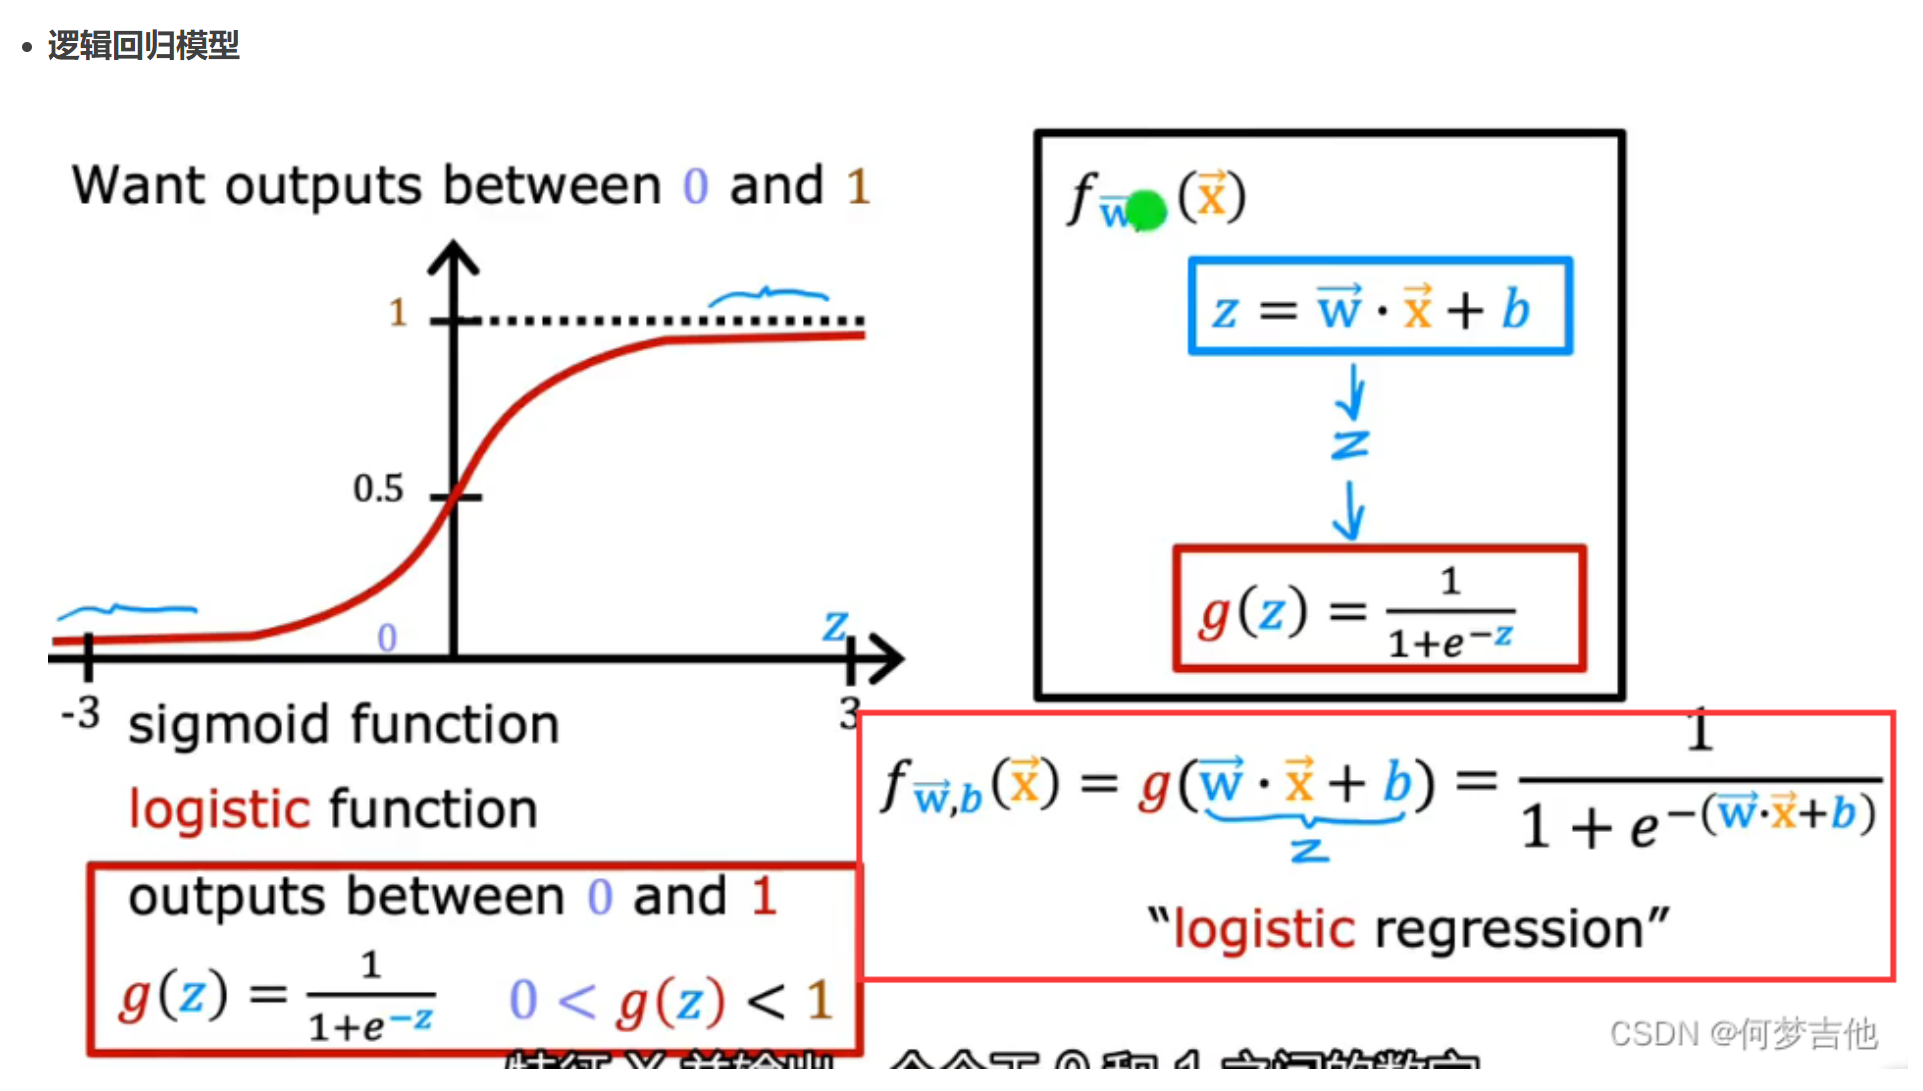

它的特点是：

- 当 $z$ 很大时，$g(z)$ 接近 1。
- 当 $z$ 很小时，$g(z)$ 接近 0。
- 当 $z = 0$ 时，$g(z) = 0.5$。

### 10.3 假设函数

逻辑回归的假设函数为：

$$
f_{\mathbf{w},b}(\mathbf{x}) = g(\mathbf{w} \cdot \mathbf{x} + b)
= \frac{1}{1 + e^{-(\mathbf{w} \cdot \mathbf{x} + b)}}
$$

其中：

- $f_{\mathbf{w},b}(\mathbf{x})$：预测为正类的概率
- $\mathbf{w}$：权重参数
- $b$：偏置参数
- $\mathbf{x}$：输入特征向量

通常可以用阈值进行分类：

- $f_{\mathbf{w},b}(\mathbf{x}) \ge 0.5$，预测为 1 类。
- $f_{\mathbf{w},b}(\mathbf{x}) < 0.5$，预测为 0 类。

### 10.4 代价函数

逻辑回归常用的代价函数是交叉熵损失（Cross-Entropy Loss）：

$$
J(\mathbf{w}, b) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(f_{\mathbf{w},b}(\mathbf{x}^{(i)})) + (1-y^{(i)})\log(1-f_{\mathbf{w},b}(\mathbf{x}^{(i)}))\right]
$$

其中：

- $m$：训练样本数量
- $y^{(i)}$：第 $i$ 个样本的真实标签，通常为 0 或 1
- $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$：第 $i$ 个样本预测为正类的概率

### 10.5 梯度下降

逻辑回归也可以用梯度下降训练参数。它和线性回归的更新形式看起来相似，但本质不同，因为两者的假设函数和代价函数不同。

## 11. 决策边界 Decision Boundary

### 11.1 定义

决策边界是分类器用来区分不同类别的边界线或区域。它会把特征空间划分成不同部分，每一部分对应一个预测类别。

在逻辑回归中，如果分类阈值是 0.5，那么决策边界通常由下面的条件决定：

$$
\mathbf{w} \cdot \mathbf{x} + b = 0
$$

因为当 $z = 0$ 时，Sigmoid 函数输出 $0.5$。

### 11.2 分类器类型

| 类型 | 决策边界形状 | 例子 |
| --- | --- | --- |
| 线性分类器 | 直线或超平面 | 逻辑回归、线性 SVM |
| 非线性分类器 | 曲线或更复杂的区域 | 决策树、随机森林、神经网络 |

### 11.3 作用

1. **区分类别**：将数据划分到不同类别区域。
2. **帮助可视化**：可以直观观察模型如何分类样本。
3. **辅助评估模型**：观察决策边界是否过于简单或过于复杂。

---

## 12. 过拟合与欠拟合

### 12.1 过拟合 Overfitting（高方差）

过拟合是指：模型在训练数据上表现很好，但在测试数据或新数据上表现较差。

本质原因是模型过于复杂，把训练数据中的噪声和细节也学进去了，导致泛化能力下降。

常见表现：

- 训练误差很低。
- 测试误差较高。
- 模型对训练集记得太细，对新数据适应能力差。

解决方法：

1. **正则化**：在损失函数中加入惩罚项，限制模型参数过大。
2. **增加数据量**：让模型看到更多样本，提高泛化能力。
3. **交叉验证**：更稳定地评估模型在不同数据划分下的表现。
4. **降低模型复杂度**：减少特征数量、降低多项式次数或简化模型结构。

### 12.2 欠拟合 Underfitting（高偏差）

欠拟合是指：模型在训练数据上表现就不好，无法捕捉数据中的主要规律。

本质原因是模型过于简单，表达能力不足。

常见表现：

- 训练误差较高。
- 测试误差也较高。
- 模型没有学到数据中的主要模式。

解决方法：

1. **增加模型复杂度**：使用更复杂的模型或增加模型参数。
2. **增加有效特征**：通过特征工程提取更有用的信息。
3. **减少过强的正则化**：如果正则化太强，模型可能被限制得过于简单。
4. **训练更久或调整优化方法**：确保模型有机会充分学习。

### 12.3 对比总结

| 问题 | 训练集表现 | 测试集表现 | 主要原因 | 常见解决方向 |
| --- | --- | --- | --- | --- |
| 过拟合 | 好 | 差 | 模型太复杂，学到噪声 | 正则化、增加数据、降低复杂度 |
| 欠拟合 | 差 | 差 | 模型太简单，学习能力不足 | 增加特征、提高复杂度、减弱正则化 |

---

## 13. 正则化 Regularization

### 13.1 定义

正则化是一种用于**防止过拟合**的方法。它会在原来的代价函数中加入一个惩罚项，限制模型参数不能变得过大。

直观理解：

- 没有正则化：模型可能为了拟合训练集，把参数调得很大，导致曲线过于复杂。
- 加入正则化：模型会在“拟合训练数据”和“保持模型简单”之间取得平衡。

### 13.2 为什么正则化能防止过拟合

过拟合通常是因为模型太复杂，学习了训练集中的噪声和细节。正则化通过惩罚过大的参数，让模型不要过度依赖某些特征，从而提高泛化能力。

正则化的核心思想是：

$$
\text{新的代价函数} = \text{原来的代价函数} + \text{正则化项}
$$

### 13.3 正则化参数 Lambda

正则化强度通常用 $\lambda$ 表示。

- $\lambda$ 太小：正则化作用弱，可能仍然过拟合。
- $\lambda$ 太大：惩罚太强，模型可能过于简单，导致欠拟合。
- $\lambda$ 合适：可以减少过拟合，同时保持较好的预测能力。

### 13.4 L2 正则化 Ridge Regularization

L2 正则化会惩罚参数的平方和，使参数整体变小，但通常不会让参数直接变成 0。

在线性回归中，加入 L2 正则化后的代价函数为：

$$
J(\mathbf{w}, b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)^2 + \frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2
$$

其中：

- $\lambda$：正则化参数，控制惩罚强度
- $w_j$：第 $j$ 个权重参数
- $n$：特征数量

注意：通常只正则化权重 $w$，不正则化偏置 $b$。

### 13.5 L1 正则化 Lasso Regularization

L1 正则化会惩罚参数绝对值之和：

$
\frac{\lambda}{m}\sum_{j=1}^{n}\lvert w_j \rvert
$

L1 正则化的特点是：它可能让某些参数变成 0，因此可以起到**特征选择**的作用。

简单来说：

- L1 正则化：可能让部分权重变成 0，适合做特征选择。
- L2 正则化：让权重整体变小，训练更稳定，实际使用更常见。

### 13.6 逻辑回归中的正则化

逻辑回归也可以加入正则化，用来防止分类边界过于复杂。

加入 L2 正则化后的逻辑回归代价函数为：

$$
J(\mathbf{w}, b) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(f_{\mathbf{w},b}(\mathbf{x}^{(i)})) + (1-y^{(i)})\log(1-f_{\mathbf{w},b}(\mathbf{x}^{(i)}))\right] + \frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2
$$

它的作用仍然是限制参数过大，让决策边界不要过度弯曲，从而减少过拟合。

### 13.7 总结

| 方法 | 惩罚项 | 主要作用 | 特点 |
| --- | --- | --- | --- |
| L1 正则化 | $\sum_{j=1}^{n} \lvert w_j \rvert$ | 防止过拟合，辅助特征选择 | 可能让部分权重变成 0 |
| L2 正则化 | $\sum w_j^2$ | 防止过拟合，让模型更平滑 | 权重整体变小，实际更常用 |

记忆方式：

- 正则化是给模型加“约束”，防止它在训练集上学得太死。
- $\lambda$ 控制约束强度。
- $\lambda$ 过小容易过拟合，$\lambda$ 过大容易欠拟合。

---

## 14. 分类和回归的评价指标

### 14.1 为什么需要评价指标

训练模型之后，需要用评价指标判断模型在数据上的表现。不同任务的输出形式不同，所以分类问题和回归问题常用的评价指标也不同。

- **分类问题**：预测的是类别，例如 0 或 1、猫或狗、正常或异常。
- **回归问题**：预测的是连续数值，例如房价、温度、销量。

选择评价指标时，要结合任务目标，而不是只看一个分数。例如类别极度不平衡时，准确率可能很高，但模型并不一定真正有用。

### 14.2 分类问题的混淆矩阵 Confusion Matrix

二分类问题中，可以先用混淆矩阵统计预测结果：

| 实际类别 / 预测类别 | 预测为正类 | 预测为负类 |
| --- | --- | --- |
| 实际为正类 | TP | FN |
| 实际为负类 | FP | TN |

其中：

- TP（True Positive）：实际为正类，预测也为正类。
- TN（True Negative）：实际为负类，预测也为负类。
- FP（False Positive）：实际为负类，但预测为正类。
- FN（False Negative）：实际为正类，但预测为负类。

后面的准确率、精确率、召回率等指标，都是基于这些数量计算出来的。

### 14.3 准确率 Accuracy

准确率表示所有样本中预测正确的比例：

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

准确率容易理解，适合类别分布比较均衡的情况。但如果数据类别严重不平衡，准确率可能会产生误导。

例如 100 个样本中有 95 个负类、5 个正类，模型全部预测为负类，也能得到 95% 的准确率，但它完全没有识别出正类。

### 14.4 精确率 Precision 和召回率 Recall

精确率表示：模型预测为正类的样本中，有多少是真的正类。

$$
Precision = \frac{TP}{TP + FP}
$$

召回率表示：真实正类样本中，有多少被模型成功找出来。

$$
Recall = \frac{TP}{TP + FN}
$$

简单理解：

- Precision 更关注“预测为正的结果是否可靠”。
- Recall 更关注“真实正类是否尽量被找全”。

当误报代价较高时，更关注 Precision；当漏报代价较高时，更关注 Recall。

### 14.5 F1 Score

F1 Score 是 Precision 和 Recall 的调和平均数，用来综合衡量二者：

$$
F1 = \frac{2 \times Precision \times Recall}{Precision + Recall}
$$

F1 Score 适合在 Precision 和 Recall 都重要时使用。它不会只因为某一个指标很高就得到很高的分数。

### 14.6 ROC 曲线和 AUC

逻辑回归等模型通常会输出属于正类的概率。改变分类阈值，会得到不同的真正率和假正率。

真正率 TPR 也就是召回率：

$$
TPR = \frac{TP}{TP + FN}
$$

假正率 FPR 表示真实负类中被错误预测为正类的比例：

$$
FPR = \frac{FP}{FP + TN}
$$

ROC 曲线以 FPR 为横轴、TPR 为纵轴，观察模型在不同阈值下的分类能力。AUC 是 ROC 曲线下面积，通常越接近 1，模型区分正负类的能力越强。

### 14.7 回归问题的评价指标

回归问题预测的是连续数值，评价时通常关注预测值和真实值之间的误差。设真实值为 $y^{(i)}$，预测值为 $\hat{y}^{(i)}$，样本数量为 $m$。

### 14.8 平均绝对误差 MAE

MAE 表示预测误差绝对值的平均值：

$$
MAE = \frac{1}{m}\sum_{i=1}^{m}\lvert y^{(i)} - \hat{y}^{(i)} \rvert
$$

MAE 的单位和原始标签相同，比较容易解释。它对异常值的敏感程度相对较低。

### 14.9 均方误差 MSE 和均方根误差 RMSE

MSE 表示预测误差平方的平均值：

$$
MSE = \frac{1}{m}\sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)})^2
$$

RMSE 是 MSE 开根号后的结果：

$$
RMSE = \sqrt{\frac{1}{m}\sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)})^2}
$$

MSE 会放大较大的误差，因此对异常值更敏感。RMSE 的单位和原始标签相同，比 MSE 更容易直观理解。

### 14.10 决定系数 R-squared

$R^2$ 用来衡量模型对数据波动的解释能力：

$$
R^2 = 1 - \frac{\sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)})^2}{\sum_{i=1}^{m}(y^{(i)} - \bar{y})^2}
$$

其中 $\bar{y}$ 表示真实值的平均值。

通常情况下：

- $R^2$ 越接近 1，说明模型拟合效果越好。
- $R^2 = 0$，说明模型效果大致相当于直接预测平均值。
- $R^2 < 0$，说明模型可能比直接预测平均值还差。

### 14.11 对比总结

| 任务类型 | 指标 | 主要含义 | 适用情况 |
| --- | --- | --- | --- |
| 分类 | Accuracy | 预测正确的整体比例 | 类别比较均衡 |
| 分类 | Precision | 预测为正的样本有多少是真的 | 误报代价高 |
| 分类 | Recall | 真实正类有多少被找出来 | 漏报代价高 |
| 分类 | F1 Score | Precision 和 Recall 的综合表现 | 类别不平衡、二者都重要 |
| 分类 | AUC | 不同阈值下区分正负类的能力 | 需要比较模型排序能力 |
| 回归 | MAE | 平均绝对误差 | 需要直观解释误差大小 |
| 回归 | MSE | 平均平方误差 | 更重视大误差 |
| 回归 | RMSE | MSE 开根号后的误差 | 需要保留原始单位 |
| 回归 | $R^2$ | 模型解释数据波动的能力 | 衡量整体拟合程度 |

记忆方式：

- 分类问题看“分对了多少”和“正类找得准不准、全不全”。
- 回归问题看“预测值离真实值有多远”。
- 类别不平衡时，不要只看 Accuracy；回归有异常值时，要注意 MSE 和 RMSE 会被大误差明显影响。

***********